# FIFA World Cup 2026 Tournament Simulation

# Notebook Workflow

This notebook simulates the complete FIFA World Cup 2026 using the prediction engine developed in the previous notebook.

The workflow followed in this notebook is:

1. Import the required libraries.
2. Load the trained XGBoost model and feature columns.
3. Load the latest team statistics, FIFA rankings, and Elo ratings.
4. Load the official FIFA World Cup 2026 fixtures.
5. Recreate the feature engineering pipeline for tournament matches.
6. Predict the outcome probabilities for individual matches.
7. Simulate every match in the tournament using the predicted probabilities.
8. Simulate the complete FIFA World Cup, including the group stage and knockout rounds.
9. Repeat the tournament thousands of times using Monte Carlo Simulation.
10. Calculate and visualize the probability of each nation winning the FIFA World Cup 2026.

In [50]:
import pandas as pd
import numpy as np

import joblib

import random

In [51]:
model = joblib.load("../models/fifa_worldcup_xgboost.pkl")

feature_columns = joblib.load("../models/feature_columns.pkl")

In [52]:
team_statistics = pd.read_csv("../datasets/team_statistics.csv")

fixtures = pd.read_csv("../datasets/wc_2026_fixtures.csv")

In [53]:
print("Number of Teams :", len(team_statistics))

print("Number of Fixtures :", len(fixtures))

print("Number of Features :", len(feature_columns))

Number of Teams : 48
Number of Fixtures : 104
Number of Features : 18


In [54]:
latest_fifa = pd.read_csv("../datasets/fifa_rankings_.csv")
elo = pd.read_csv("../datasets/elo_ratings_wc2026.csv")

In [55]:
print(latest_fifa.columns.tolist())
print(elo.columns.tolist())

['Team', 'FIFA_Rank']
['year', 'snapshot_date', 'country', 'rank', 'country_code', 'rating', 'rank_max', 'rating_max', 'rank_avg', 'rating_avg', 'rank_min', 'rating_min', 'matches_total', 'matches_home', 'matches_away', 'matches_neutral', 'wins', 'losses', 'draws', 'goals_for', 'goals_against', 'confederation', 'is_host']


In [56]:
teams = pd.read_csv("../datasets/wc_2026_teams.csv")

set(teams["team"]) - set(team_statistics["team"])

set()

In [57]:
latest_fifa = latest_fifa.rename(
    columns={
        "Team": "team"
    }
)

latest_fifa["team"] = latest_fifa["team"].replace({
    "Cabo Verde": "Cape Verde",
    "Congo DR": "DR Congo"
})

latest_fifa.head()

,team,FIFA_Rank
0,Argentina,1
1,Spain,2
2,France,3
3,England,4
4,Portugal,5


In [58]:
elo["country"] = elo["country"].replace({
    "United States": "USA",
    "Turkey": "Türkiye"
})

latest_elo = (
    elo.sort_values("year")
       .groupby("country", as_index=False)
       .last()
)

latest_elo = latest_elo.rename(
    columns={
        "country": "team",
        "rating": "elo_rating"
    }
)

latest_elo = latest_elo[["team", "elo_rating"]]

latest_elo.head()

,team,elo_rating
0,Algeria,1743
1,Argentina,2113
2,Australia,1783
3,Austria,1827
4,Belgium,1867


In [59]:
team_statistics = team_statistics.drop(
    columns=[
        "FIFA_Rank_y",
        "elo_rating_y",
        "FIFA_Rank"
    ],
    errors="ignore"
)

team_statistics = team_statistics.rename(
    columns={
        "FIFA_Rank_x": "FIFA_Rank",
        "elo_rating_x": "elo_rating"
    }
)

In [60]:
print(team_statistics.columns)

print()

print(team_statistics.isnull().sum())

Index(['team', 'wins_last5', 'draws_last5', 'losses_last5', 'form_points',
       'goals_scored', 'goals_conceded', 'goal_difference', 'avg_goals_scored',
       'avg_goals_conceded', 'elo_rating'],
      dtype='object')

team                  0
wins_last5            0
draws_last5           0
losses_last5          0
form_points           0
goals_scored          0
goals_conceded        0
goal_difference       0
avg_goals_scored      0
avg_goals_conceded    0
elo_rating            0
dtype: int64


In [61]:
print(team_statistics.columns.tolist())

['team', 'wins_last5', 'draws_last5', 'losses_last5', 'form_points', 'goals_scored', 'goals_conceded', 'goal_difference', 'avg_goals_scored', 'avg_goals_conceded', 'elo_rating']


In [62]:

print(team_statistics.isnull().sum())

team                  0
wins_last5            0
draws_last5           0
losses_last5          0
form_points           0
goals_scored          0
goals_conceded        0
goal_difference       0
avg_goals_scored      0
avg_goals_conceded    0
elo_rating            0
dtype: int64


In [63]:
team_statistics = team_statistics.merge(
    latest_fifa[["team", "FIFA_Rank"]],
    on="team",
    how="left"
)

team_statistics = team_statistics.merge(
    latest_elo,
    on="team",
    how="left"
)

In [64]:
print(team_statistics.columns.tolist())
print()

print(team_statistics.isnull().sum())

['team', 'wins_last5', 'draws_last5', 'losses_last5', 'form_points', 'goals_scored', 'goals_conceded', 'goal_difference', 'avg_goals_scored', 'avg_goals_conceded', 'elo_rating_x', 'FIFA_Rank', 'elo_rating_y']

team                  0
wins_last5            0
draws_last5           0
losses_last5          0
form_points           0
goals_scored          0
goals_conceded        0
goal_difference       0
avg_goals_scored      0
avg_goals_conceded    0
elo_rating_x          0
FIFA_Rank             1
elo_rating_y          0
dtype: int64


In [65]:
team_statistics.drop(
    columns=["FIFA_Rank_y", "elo_rating_y"],
    inplace=True,
    errors="ignore"
)

team_statistics.rename(
    columns={
        "FIFA_Rank_x": "FIFA_Rank",
        "elo_rating_x": "elo_rating"
    },
    inplace=True
)

In [66]:
print(team_statistics.columns.tolist())

['team', 'wins_last5', 'draws_last5', 'losses_last5', 'form_points', 'goals_scored', 'goals_conceded', 'goal_difference', 'avg_goals_scored', 'avg_goals_conceded', 'elo_rating', 'FIFA_Rank']


In [67]:
print(team_statistics.isnull().sum())

team                  0
wins_last5            0
draws_last5           0
losses_last5          0
form_points           0
goals_scored          0
goals_conceded        0
goal_difference       0
avg_goals_scored      0
avg_goals_conceded    0
elo_rating            0
FIFA_Rank             1
dtype: int64


In [68]:
team_statistics.to_csv(
    "../datasets/team_statistics.csv",
    index=False
)

In [69]:
team_statistics = pd.read_csv("../datasets/team_statistics.csv")

print(team_statistics.columns.tolist())
print(team_statistics.isnull().sum())

['team', 'wins_last5', 'draws_last5', 'losses_last5', 'form_points', 'goals_scored', 'goals_conceded', 'goal_difference', 'avg_goals_scored', 'avg_goals_conceded', 'elo_rating', 'FIFA_Rank']
team                  0
wins_last5            0
draws_last5           0
losses_last5          0
form_points           0
goals_scored          0
goals_conceded        0
goal_difference       0
avg_goals_scored      0
avg_goals_conceded    0
elo_rating            0
FIFA_Rank             1
dtype: int64


In [70]:
team_statistics[team_statistics["FIFA_Rank"].isnull()][["team"]]

,team
27,New Zealand


In [71]:
team_statistics.loc[
    team_statistics["team"] == "New Zealand",
    "FIFA_Rank"
] = 86

In [72]:
print(team_statistics.isnull().sum())

team                  0
wins_last5            0
draws_last5           0
losses_last5          0
form_points           0
goals_scored          0
goals_conceded        0
goal_difference       0
avg_goals_scored      0
avg_goals_conceded    0
elo_rating            0
FIFA_Rank             0
dtype: int64


In [73]:
team_statistics.to_csv(
    "../datasets/team_statistics.csv",
    index=False
)

print("team_statistics.csv saved successfully!")

team_statistics.csv saved successfully!


# Single Match Simulation

Before simulating the complete FIFA World Cup, a helper function is created to simulate an individual match.

The trained XGBoost model predicts the probabilities of a home win, draw, and away win. A random outcome is then sampled using these probabilities, making each simulated match realistic while preserving the model's confidence.

In [74]:
def simulate_match(
    home_team,
    away_team,
    tournament="FIFA World Cup",
    host_team=None
):

    importance = {
        "Friendly": 1,
        "Nations League": 2,
        "Qualifier": 3,
        "Continental Cup": 4,
        "FIFA World Cup": 5
    }

    tournament_importance = importance.get(tournament, 1)

    tournament_type = 0

    host_advantage = 0

    if host_team is not None:
        if home_team == host_team:
            host_advantage = 1

    features = create_match_features(
        home_team,
        away_team,
        tournament_type,
        tournament_importance,
        host_advantage
    )

    features = features[feature_columns]

    probabilities = model.predict_proba(features)[0]

    outcome = np.random.choice(
        [0, 1, 2],
        p=probabilities
    )

    return outcome, probabilities

In [75]:
def create_match_features(

    home_team,

    away_team,

    tournament_type=0,

    tournament_importance=5,

    host_advantage=0

):

    home = get_team(home_team)

    away = get_team(away_team)

    features = {

        "home_elo": home["elo_rating"],

        "away_elo": away["elo_rating"],

        "elo_difference":
        home["elo_rating"] - away["elo_rating"],


        "home_fifa_rank": home["FIFA_Rank"],

        "away_fifa_rank": away["FIFA_Rank"],

        "rank_difference":
        away["FIFA_Rank"] - home["FIFA_Rank"],


        "home_form_points":
        home["form_points"],

        "away_form_points":
        away["form_points"],

        "form_difference":
        home["form_points"] - away["form_points"],


        "home_goal_diff":
        home["goal_difference"],

        "away_goal_diff":
        away["goal_difference"],

        "goal_diff_difference":
        home["goal_difference"] - away["goal_difference"],


        "home_wins_last5":
        home["wins_last5"],

        "away_wins_last5":
        away["wins_last5"],

        "wins_difference":
        home["wins_last5"] - away["wins_last5"],


        "host_advantage":
        host_advantage,

        "tournament_type":
        tournament_type,

        "tournament_importance":
        tournament_importance

    }

    features = pd.DataFrame([features])

    features = features[feature_columns]

    return features

In [76]:
def get_team(team):

    row = team_statistics[
        team_statistics["team"] == team
    ]

    if row.empty:
        raise ValueError(f"{team} not found.")

    return row.iloc[0]
    

In [77]:
print(team_statistics.columns.tolist())

['team', 'wins_last5', 'draws_last5', 'losses_last5', 'form_points', 'goals_scored', 'goals_conceded', 'goal_difference', 'avg_goals_scored', 'avg_goals_conceded', 'elo_rating', 'FIFA_Rank']


In [78]:
def simulate_group(group_matches):

    table = {}

    teams = pd.unique(
        group_matches[["team1", "team2"]].values.ravel()
    )

    for team in teams:
        table[team] = {
            "Team": team,
            "Points": 0,
            "Played": 0,
            "Wins": 0,
            "Draws": 0,
            "Losses": 0,
            "GF": 0,
            "GA": 0,
            "GD": 0
        }

    for _, match in group_matches.iterrows():

        home = match["team1"]
        away = match["team2"]

        winner, probabilities = simulate_match(home, away)

        home_prob = probabilities[2]
        draw_prob = probabilities[1]
        away_prob = probabilities[0]

        r = random.random()

        if r < home_prob:

            winner = home
            home_goals = random.choice([1, 2, 2, 3, 3, 4])
            away_goals = random.choice([0, 1, 1, 2])

        elif r < home_prob + draw_prob:

            winner = "Draw"
            g = random.choice([0, 1, 1, 2])
            home_goals = g
            away_goals = g

        else:

            winner = away
            home_goals = random.choice([0, 1, 1, 2])
            away_goals = random.choice([1, 2, 2, 3, 3, 4])

        table[home]["Played"] += 1
        table[away]["Played"] += 1

        if winner == home:

            table[home]["Points"] += 3
            table[home]["Wins"] += 1
            table[away]["Losses"] += 1

        elif winner == away:

            table[away]["Points"] += 3
            table[away]["Wins"] += 1
            table[home]["Losses"] += 1

        else:

            table[home]["Points"] += 1
            table[away]["Points"] += 1

            table[home]["Draws"] += 1
            table[away]["Draws"] += 1

        table[home]["GF"] += home_goals
        table[home]["GA"] += away_goals

        table[away]["GF"] += away_goals
        table[away]["GA"] += home_goals

    for team in teams:
        table[team]["GD"] = (
            table[team]["GF"] - table[team]["GA"]
        )

    standings = pd.DataFrame(table.values())

    standings = standings.sort_values(
        by=["Points", "GD", "GF"],
        ascending=False
    ).reset_index(drop=True)

    return standings

In [150]:
def simulate_all_groups(fixtures, verbose=True):

    fixtures = fixtures.dropna(subset=["group"])

    groups = sorted(fixtures["group"].unique())

    all_tables = {}

    for group in groups:

        if verbose:
            print("=" * 50)
            print(f"Group {group}")
            print("=" * 50)

        group_matches = fixtures[
            fixtures["group"] == group
        ]

        standings = simulate_group(group_matches)

        if verbose:
            print(standings)
            print()

        all_tables[group] = standings

    return all_tables

In [151]:
fixtures.head()

,group,stage,team1,team2,venue,city,country,date,kickoff_et,team1_confederation,team1_fifa_rank,team1_coach,team2_confederation,team2_fifa_rank,team2_coach
0,A,Group Stage,Mexico,South Africa,Estadio Azteca,Mexico City,Mexico,2026-06-11,20:00 ET,CONCACAF,15.0,Javier Aguirre,CAF,60.0,Hugo Broos
1,A,Group Stage,South Korea,Czechia,Estadio Akron,Guadalajara,Mexico,2026-06-11,22:00 ET,AFC,25.0,Hong Myung-bo,UEFA,41.0,Ivan Hasek
2,A,Group Stage,South Korea,Mexico,Estadio Akron,Guadalajara,Mexico,2026-06-18,21:00 ET,AFC,25.0,Hong Myung-bo,CONCACAF,15.0,Javier Aguirre
3,A,Group Stage,Czechia,South Africa,Estadio Akron,Guadalajara,Mexico,2026-06-18,18:00 ET,UEFA,41.0,Ivan Hasek,CAF,60.0,Hugo Broos
4,A,Group Stage,Czechia,Mexico,Estadio Azteca,Mexico City,Mexico,2026-06-24,21:00 ET,UEFA,41.0,Ivan Hasek,CONCACAF,15.0,Javier Aguirre


In [81]:
group_tables = simulate_all_groups(fixtures)

Group A
           Team  Points  Played  Wins  Draws  Losses  GF  GA  GD
0        Mexico       9       3     3      0       0   9   4   5
1   South Korea       6       3     2      0       1   6   7  -1
2       Czechia       3       3     1      0       2   5   7  -2
3  South Africa       0       3     0      0       3   3   5  -2

Group B
                     Team  Points  Played  Wins  Draws  Losses  GF  GA  GD
0             Switzerland       7       3     2      1       0   5   1   4
1                  Canada       7       3     2      1       0   5   2   3
2                   Qatar       3       3     1      0       2   6   8  -2
3  Bosnia and Herzegovina       0       3     0      0       3   2   7  -5

Group C
       Team  Points  Played  Wins  Draws  Losses  GF  GA  GD
0  Scotland       7       3     2      1       0   5   2   3
1    Brazil       4       3     1      1       1   5   2   3
2   Morocco       4       3     1      1       1   5   7  -2
3     Haiti       1       3   

# Monte Carlo World Cup Simulation

Instead of simulating the tournament only once, we now simulate the complete FIFA World Cup thousands of times.

The objective is to estimate:

- Probability of winning each group
- Probability of qualifying for Round of 32
- Probability of reaching each knockout round
- Probability of winning the FIFA World Cup

These probabilities are obtained using Monte Carlo Simulation.

In [82]:
teams = sorted(team_statistics["team"].unique())

results = {}

for team in teams:
    results[team] = {
        "Group Wins": 0,
        "Round of 32": 0,
        "Round of 16": 0,
        "Quarter Final": 0,
        "Semi Final": 0,
        "Final": 0,
        "Champion": 0
    }

## Group Stage Simulation

The group stage is simulated first.

After each tournament simulation, the winning team of every group and the two qualified teams are stored.

These counts will later be converted into probabilities.

In [83]:
def get_group_qualifiers(group_tables):

    winners = {}
    qualifiers = {}

    for group, table in group_tables.items():

        winners[group] = table.iloc[0]["Team"]

        qualifiers[group] = [
            table.iloc[0]["Team"],
            table.iloc[1]["Team"]
        ]

    return winners, qualifiers

In [84]:
winners, qualifiers = get_group_qualifiers(group_tables)

print(winners)

{'A': 'Mexico', 'B': 'Switzerland', 'C': 'Scotland', 'D': 'Türkiye', 'E': 'Ecuador', 'F': 'Netherlands', 'G': 'Belgium', 'H': 'Spain', 'I': 'France', 'J': 'Argentina', 'K': 'Colombia', 'L': 'England'}


In [85]:
print(qualifiers["A"])

['Mexico', 'South Korea']


# Determine the Best Third-Placed Teams

In the FIFA World Cup 2026 format, the top two teams from each group automatically qualify for the Round of 32.

In addition, the **8 best third-placed teams** across all 12 groups also qualify.

Teams are ranked using the official FIFA tie-breaking criteria:

1. Points
2. Goal Difference (GD)
3. Goals Scored (GF)

This function extracts the third-placed team from every group and ranks them.

In [86]:
def get_best_third_placed(group_tables):

    third_place = []

    for group, table in group_tables.items():

        team = table.iloc[2]

        third_place.append({
            "Group": group,
            "Team": team["Team"],
            "Points": team["Points"],
            "GD": team["GD"],
            "GF": team["GF"]
        })

    third_place = pd.DataFrame(third_place)

    third_place = third_place.sort_values(
        by=["Points", "GD", "GF"],
        ascending=False
    ).reset_index(drop=True)

    best8 = third_place.head(8)

    return third_place, best8

In [87]:
third_table, best8 = get_best_third_placed(group_tables)

print(third_table)

   Group         Team  Points  GD  GF
0      F       Sweden       4   1   6
1      K     Portugal       4   0   5
2      G        Egypt       4  -1   4
3      C      Morocco       4  -2   5
4      L       Panama       3  -1   7
5      I      Senegal       3  -1   6
6      B        Qatar       3  -2   6
7      A      Czechia       3  -2   5
8      E  Ivory Coast       3  -2   4
9      D          USA       3  -3   4
10     J      Algeria       3  -3   4
11     H   Cape Verde       3  -3   3


In [88]:
print(best8)

  Group      Team  Points  GD  GF
0     F    Sweden       4   1   6
1     K  Portugal       4   0   5
2     G     Egypt       4  -1   4
3     C   Morocco       4  -2   5
4     L    Panama       3  -1   7
5     I   Senegal       3  -1   6
6     B     Qatar       3  -2   6
7     A   Czechia       3  -2   5


# Qualified Teams

The Round of 32 consists of:

- 12 Group Winners
- 12 Group Runners-up
- 8 Best Third-Placed Teams

The following function combines these qualified teams into a single structure that will later be used to generate the official Round of 32 bracket.

In [89]:
def get_qualified_teams(winners, qualifiers, best8):

    qualified = {}

    for group in sorted(winners.keys()):

        qualified[group + "1"] = qualifiers[group][0]
        qualified[group + "2"] = qualifiers[group][1]

    for _, row in best8.iterrows():

        qualified[row["Group"] + "3"] = row["Team"]

    return qualified

In [90]:
qualified = get_qualified_teams(
    winners,
    qualifiers,
    best8
)

print(qualified)

{'A1': 'Mexico', 'A2': 'South Korea', 'B1': 'Switzerland', 'B2': 'Canada', 'C1': 'Scotland', 'C2': 'Brazil', 'D1': 'Türkiye', 'D2': 'Paraguay', 'E1': 'Ecuador', 'E2': 'Germany', 'F1': 'Netherlands', 'F2': 'Japan', 'G1': 'Belgium', 'G2': 'Iran', 'H1': 'Spain', 'H2': 'Uruguay', 'I1': 'France', 'I2': 'Norway', 'J1': 'Argentina', 'J2': 'Austria', 'K1': 'Colombia', 'K2': 'Uzbekistan', 'L1': 'England', 'L2': 'Croatia', 'F3': 'Sweden', 'K3': 'Portugal', 'G3': 'Egypt', 'C3': 'Morocco', 'L3': 'Panama', 'I3': 'Senegal', 'B3': 'Qatar', 'A3': 'Czechia'}


In [91]:
print(f"Qualified Teams : {len(qualified)}")

Qualified Teams : 32


# Official FIFA 2026 Round of 32

The FIFA World Cup 2026 uses 12 groups.

The Round of 32 consists of:

- 12 Group Winners
- 12 Group Runners-up
- 8 Best Third-Placed Teams

Unlike previous editions of the FIFA World Cup, the Round of 32 bracket is **dynamic**. The fixtures depend on which eight third-placed teams qualify.

Therefore, we first identify the qualifying third-place groups and then generate the official knockout bracket.

In [92]:
third_place_groups = sorted([
    key[0]
    for key in qualified.keys()
    if key.endswith("3")
])

print("Qualified Third Place Groups:")
print(third_place_groups)

Qualified Third Place Groups:
['A', 'B', 'C', 'F', 'G', 'I', 'K', 'L']


In [93]:
print(type(third_place_lookup))
print(len(third_place_lookup))

<class 'dict'>
495


In [105]:
from openpyxl import load_workbook

def make_third_place_lookup(path):

    wb = load_workbook(path, data_only=True)
    ws = wb.active

    lookup = {}

    # Convert Excel format (3C) -> Project format (C3)
    def convert(slot):

        if slot is None:
            return None

        slot = str(slot).strip()

        if len(slot) == 2 and slot[0] == "3":
            return slot[1] + "3"

        return slot

    for row in ws.iter_rows(values_only=True):

        # Qualified third-place groups (Columns B-M)
        groups = []

        for g in row[1:13]:
            if g is not None:
                groups.append(str(g).strip())

        groups = tuple(sorted(groups))

        # Official FIFA assignments (Columns O-V)
        mapping = {
            "79": convert(row[14]),   # 1A vs ...
            "85": convert(row[15]),   # 1B vs ...
            "81": convert(row[16]),   # 1D vs ...
            "74": convert(row[17]),   # 1E vs ...
            "82": convert(row[18]),   # 1G vs ...
            "77": convert(row[19]),   # 1I vs ...
            "87": convert(row[20]),   # 1K vs ...
            "80": convert(row[21])    # 1L vs ...
        }

        lookup[groups] = mapping

    return lookup

In [106]:
third_place_lookup = make_third_place_lookup(
    "../datasets/fifa_2026_lookup.xlsx"
)

print(len(third_place_lookup))

495


In [107]:
third_place_groups = sorted([
    key[0]
    for key in qualified.keys()
    if key.endswith("3")
])

print(third_place_groups)

['A', 'B', 'C', 'F', 'G', 'I', 'K', 'L']


In [108]:
qualified_key = tuple(third_place_groups)

print(qualified_key)

('A', 'B', 'C', 'F', 'G', 'I', 'K', 'L')


In [109]:
third_place_mapping = third_place_lookup[qualified_key]

print(third_place_mapping)

{'79': 'I3', '85': 'G3', '81': 'B3', '74': 'C3', '82': 'A3', '77': 'F3', '87': 'L3', '80': 'K3'}


In [110]:
def build_round_of_32(qualified, third_place_mapping):

    bracket = {}

    # Fixed Matches
    bracket["73"] = (qualified["A2"], qualified["B2"])
    bracket["75"] = (qualified["F1"], qualified["C2"])
    bracket["76"] = (qualified["C1"], qualified["F2"])
    bracket["78"] = (qualified["E2"], qualified["I2"])
    bracket["83"] = (qualified["K2"], qualified["L2"])
    bracket["84"] = (qualified["H1"], qualified["J2"])
    bracket["86"] = (qualified["J1"], qualified["H2"])
    bracket["88"] = (qualified["D2"], qualified["G2"])

    # Matches involving 3rd-place teams
    bracket["74"] = (
        qualified["E1"],
        qualified[third_place_mapping["74"]]
    )

    bracket["77"] = (
        qualified["I1"],
        qualified[third_place_mapping["77"]]
    )

    bracket["79"] = (
        qualified["A1"],
        qualified[third_place_mapping["79"]]
    )

    bracket["80"] = (
        qualified["L1"],
        qualified[third_place_mapping["80"]]
    )

    bracket["81"] = (
        qualified["D1"],
        qualified[third_place_mapping["81"]]
    )

    bracket["82"] = (
        qualified["G1"],
        qualified[third_place_mapping["82"]]
    )

    bracket["85"] = (
        qualified["B1"],
        qualified[third_place_mapping["85"]]
    )

    bracket["87"] = (
        qualified["K1"],
        qualified[third_place_mapping["87"]]
    )

    return bracket

In [111]:
round32 = build_round_of_32(
    qualified,
    third_place_mapping
)

for match, teams in sorted(round32.items()):
    print(f"Match {match}: {teams[0]} vs {teams[1]}")

Match 73: South Korea vs Canada
Match 74: Ecuador vs Morocco
Match 75: Netherlands vs Brazil
Match 76: Scotland vs Japan
Match 77: France vs Sweden
Match 78: Germany vs Norway
Match 79: Mexico vs Senegal
Match 80: England vs Portugal
Match 81: Türkiye vs Qatar
Match 82: Belgium vs Czechia
Match 83: Uzbekistan vs Croatia
Match 84: Spain vs Austria
Match 85: Switzerland vs Egypt
Match 86: Argentina vs Uruguay
Match 87: Colombia vs Panama
Match 88: Paraguay vs Iran


# Simulating the Knockout Stage

The official Round of 32 bracket has now been generated.

The remaining tournament follows a fixed knockout format.

Each knockout match is simulated using the trained prediction model.

The winner advances to the next round until a FIFA World Cup champion is determined.

The simulation will proceed through:

- Round of 32
- Round of 16
- Quarter-finals
- Semi-finals
- Third-place Playoff
- Final

In [163]:
def simulate_knockout_match(
    team1,
    team2,
    tournament="FIFA World Cup",
    host_team=None
):

    outcome, probabilities = simulate_match(
        team1,
        team2,
        tournament=tournament,
        host_team=host_team
    )

    # 2 = Home win
    if outcome == 2:
        return team1

    # 0 = Away win
    if outcome == 0:
        return team2

    # Draw
    home_prob = probabilities[2]
    away_prob = probabilities[0]

    probs = np.array([home_prob, away_prob], dtype=float)
    probs /= probs.sum()

    return np.random.choice(
        [team1, team2],
        p=probs
    )

In [164]:
winner = simulate_knockout_match(
    "Brazil",
    "Argentina"
)

print("Winner:", winner)

Winner: Argentina


In [165]:
wins = {}

for _ in range(1000):

    winner = simulate_knockout_match(
        "Brazil",
        "Argentina"
    )

    wins[winner] = wins.get(winner, 0) + 1

print(wins)

{np.str_('Brazil'): 200, 'Argentina': 800}


# Simulating a Knockout Round

Each knockout round consists of a set of fixtures.

Every match is simulated independently using the trained prediction model.

The winner of each fixture advances to the next round, producing the list of teams for the following stage.

In [166]:
def simulate_round(fixtures):

    winners = []

    for match_id in sorted(fixtures.keys()):

        team1, team2 = fixtures[match_id]

        winner = simulate_knockout_match(
            team1,
            team2
        )

        print(
            f"Match {match_id}: "
            f"{team1} vs {team2}  -->  {winner}"
        )

        winners.append(str(winner))

    return winners

In [167]:
round16_teams = simulate_round(round32)

print()
print("Qualified for Round of 16")
print(round16_teams)

Match 73: South Korea vs Canada  -->  Canada
Match 74: Ecuador vs Morocco  -->  Ecuador
Match 75: Netherlands vs Brazil  -->  Brazil
Match 76: Scotland vs Japan  -->  Japan
Match 77: France vs Sweden  -->  France
Match 78: Germany vs Norway  -->  Germany
Match 79: Mexico vs Senegal  -->  Senegal
Match 80: England vs Portugal  -->  Portugal
Match 81: Türkiye vs Qatar  -->  Türkiye
Match 82: Belgium vs Czechia  -->  Belgium
Match 83: Uzbekistan vs Croatia  -->  Croatia
Match 84: Spain vs Austria  -->  Spain
Match 85: Switzerland vs Egypt  -->  Switzerland
Match 86: Argentina vs Uruguay  -->  Uruguay
Match 87: Colombia vs Panama  -->  Colombia
Match 88: Paraguay vs Iran  -->  Paraguay

Qualified for Round of 16
['Canada', 'Ecuador', 'Brazil', 'Japan', 'France', 'Germany', 'Senegal', 'Portugal', 'Türkiye', 'Belgium', 'Croatia', 'Spain', 'Switzerland', 'Uruguay', 'Colombia', 'Paraguay']


# Round of 16

The winners from the Round of 32 advance to the Round of 16.

Unlike the group stage, the knockout bracket is fixed according to the official FIFA World Cup 2026 schedule.

The following fixtures are generated directly from the Round of 32 winners before simulating each match.

In [168]:
def build_round_of_16(round32_winners):

    bracket = {}

    bracket["89"] = (
        round32_winners[0],
        round32_winners[1]
    )

    bracket["90"] = (
        round32_winners[2],
        round32_winners[3]
    )

    bracket["91"] = (
        round32_winners[4],
        round32_winners[5]
    )

    bracket["92"] = (
        round32_winners[6],
        round32_winners[7]
    )

    bracket["93"] = (
        round32_winners[8],
        round32_winners[9]
    )

    bracket["94"] = (
        round32_winners[10],
        round32_winners[11]
    )

    bracket["95"] = (
        round32_winners[12],
        round32_winners[13]
    )

    bracket["96"] = (
        round32_winners[14],
        round32_winners[15]
    )

    return bracket

In [169]:
print(type(round16_teams))
print(round16_teams)

<class 'list'>
['Canada', 'Ecuador', 'Brazil', 'Japan', 'France', 'Germany', 'Senegal', 'Portugal', 'Türkiye', 'Belgium', 'Croatia', 'Spain', 'Switzerland', 'Uruguay', 'Colombia', 'Paraguay']


In [170]:
round16 = build_round_of_16(round16_teams)

for match, teams in sorted(round16.items()):
    print(f"Match {match}: {teams[0]} vs {teams[1]}")

Match 89: Canada vs Ecuador
Match 90: Brazil vs Japan
Match 91: France vs Germany
Match 92: Senegal vs Portugal
Match 93: Türkiye vs Belgium
Match 94: Croatia vs Spain
Match 95: Switzerland vs Uruguay
Match 96: Colombia vs Paraguay


In [171]:
quarterfinal_teams = simulate_round(round16)

print()
print("Qualified for Quarter-finals")
print(quarterfinal_teams)

Match 89: Canada vs Ecuador  -->  Ecuador
Match 90: Brazil vs Japan  -->  Brazil
Match 91: France vs Germany  -->  France
Match 92: Senegal vs Portugal  -->  Portugal
Match 93: Türkiye vs Belgium  -->  Türkiye
Match 94: Croatia vs Spain  -->  Spain
Match 95: Switzerland vs Uruguay  -->  Uruguay
Match 96: Colombia vs Paraguay  -->  Colombia

Qualified for Quarter-finals
['Ecuador', 'Brazil', 'France', 'Portugal', 'Türkiye', 'Spain', 'Uruguay', 'Colombia']


In [172]:
def build_quarterfinals(teams):

    bracket = {}

    bracket["97"] = (teams[0], teams[1])
    bracket["98"] = (teams[2], teams[3])
    bracket["99"] = (teams[4], teams[5])
    bracket["100"] = (teams[6], teams[7])

    return bracket

In [173]:
quarterfinals = build_quarterfinals(quarterfinal_teams)

for match, teams in sorted(quarterfinals.items()):
    print(f"Match {match}: {teams[0]} vs {teams[1]}")

Match 100: Uruguay vs Colombia
Match 97: Ecuador vs Brazil
Match 98: France vs Portugal
Match 99: Türkiye vs Spain


# Simulating the Quarter-finals

The eight remaining teams compete in four Quarter-final matches.

Each match is simulated independently using the trained prediction model.

The winners advance to the Semi-finals.

In [174]:
semifinal_teams = simulate_round(quarterfinals)

print()
print("Qualified for Semi-finals")
print(semifinal_teams)

Match 100: Uruguay vs Colombia  -->  Uruguay
Match 97: Ecuador vs Brazil  -->  Ecuador
Match 98: France vs Portugal  -->  France
Match 99: Türkiye vs Spain  -->  Spain

Qualified for Semi-finals
['Uruguay', 'Ecuador', 'France', 'Spain']


In [175]:
def build_semifinals(teams):

    bracket = {}

    bracket["101"] = (
        teams[0],
        teams[1]
    )

    bracket["102"] = (
        teams[2],
        teams[3]
    )

    return bracket

In [176]:
semifinals = build_semifinals(semifinal_teams)

for match, teams in sorted(semifinals.items()):
    print(f"Match {match}: {teams[0]} vs {teams[1]}")

Match 101: Uruguay vs Ecuador
Match 102: France vs Spain


# Simulating the Semi-finals

The four remaining teams compete in two Semi-final matches.

The winners advance to the FIFA World Cup Final, while the losing teams move to the Third-place Playoff.

Both winners and losers are stored for the remaining stages of the tournament.

In [177]:
def simulate_semifinals(bracket):

    finalists = []
    third_place_teams = []

    print()

    for match, teams in sorted(bracket.items()):

        winner = simulate_knockout_match(
            teams[0],
            teams[1]
        )

        loser = teams[1] if winner == teams[0] else teams[0]

        print(f"Match {match}: {teams[0]} vs {teams[1]}  -->  {winner}")

        finalists.append(winner)
        third_place_teams.append(loser)

    return finalists, third_place_teams

In [178]:
finalists, third_place_teams = simulate_semifinals(semifinals)

print()
print("Finalists")
print(finalists)

print()
print("Third-place Playoff Teams")
print(third_place_teams)


Match 101: Uruguay vs Ecuador  -->  Ecuador
Match 102: France vs Spain  -->  Spain

Finalists
['Ecuador', np.str_('Spain')]

Third-place Playoff Teams
['Uruguay', 'France']


In [179]:
def build_final_matches(finalists, third_place_teams):

    final = {
        "104": (
            finalists[0],
            finalists[1]
        )
    }

    third_place = {
        "103": (
            third_place_teams[0],
            third_place_teams[1]
        )
    }

    return final, third_place

In [180]:
final_match, third_place_match = build_final_matches(
    finalists,
    third_place_teams
)

print("\nThird-place Playoff")
for match, teams in third_place_match.items():
    print(f"Match {match}: {teams[0]} vs {teams[1]}")

print("\nFinal")
for match, teams in final_match.items():
    print(f"Match {match}: {teams[0]} vs {teams[1]}")


Third-place Playoff
Match 103: Uruguay vs France

Final
Match 104: Ecuador vs Spain


# Simulating the Final Matches

The final two matches determine the final tournament standings.

- Match 103 decides the third-place team.
- Match 104 determines the FIFA World Cup champion.

These are the last matches of a single tournament simulation.

In [181]:
third_place_winner = simulate_knockout_match(
    third_place_teams[0],
    third_place_teams[1]
)

runner_up_third = (
    third_place_teams[1]
    if third_place_winner == third_place_teams[0]
    else third_place_teams[0]
)

champion = simulate_knockout_match(
    finalists[0],
    finalists[1]
)

runner_up = (
    finalists[1]
    if champion == finalists[0]
    else finalists[0]
)

In [182]:
print("=" * 50)
print(" FIFA WORLD CUP 2026")
print("=" * 50)

print(f"\nChampion        : {champion}")
print(f"Runner-up       : {runner_up}")
print(f"Third Place     : {third_place_winner}")
print(f"Fourth Place    : {runner_up_third}")

 FIFA WORLD CUP 2026

Champion        : Spain
Runner-up       : Ecuador
Third Place     : France
Fourth Place    : Uruguay


# Monte Carlo World Cup Simulation

The entire FIFA World Cup simulation pipeline is wrapped into a single function.

Each call to this function simulates one complete FIFA World Cup, from the group stage to the final.

This function will later be executed thousands of times to estimate each team's probability of reaching different stages of the tournament.

In [192]:
def simulate_world_cup():

    # ---------------- Group Stage ----------------

    group_tables = simulate_all_groups(
        fixtures,
        verbose=False
    )

    winners, qualifiers = get_group_qualifiers(group_tables)

    third_place, best8 = get_best_third_placed(group_tables)

    qualified = get_qualified_teams(
        winners,
        qualifiers,
        best8
    )

    # ---------------- Round of 32 ----------------

    third_place_groups = sorted([
        key[0]
        for key in qualified.keys()
        if key.endswith("3")
    ])

    qualified_key = tuple(third_place_groups)

    third_place_mapping = third_place_lookup[qualified_key]

    round32 = build_round_of_32(
        qualified,
        third_place_mapping
    )

    round16_teams = simulate_round(round32)

    # ---------------- Round of 16 ----------------

    round16 = build_round_of_16(round16_teams)

    quarterfinal_teams = simulate_round(round16)

    # ---------------- Quarter-finals ----------------

    quarterfinals = build_quarterfinals(
        quarterfinal_teams
    )

    semifinal_teams = simulate_round(
        quarterfinals
    )

    # ---------------- Semi-finals ----------------

    semifinals = build_semifinals(
        semifinal_teams
    )

    finalists, third_place_teams = simulate_semifinals(
        semifinals
    )

    # ---------------- Final ----------------

    final_match, third_place_match = build_final_matches(
        finalists,
        third_place_teams
    )

    third_place_winner = simulate_knockout_match(
        third_place_teams[0],
        third_place_teams[1]
    )

    runner_up_third = (
        third_place_teams[1]
        if third_place_winner == third_place_teams[0]
        else third_place_teams[0]
    )

    champion = simulate_knockout_match(
        finalists[0],
        finalists[1]
    )

    runner_up = (
        finalists[1]
        if champion == finalists[0]
        else finalists[0]
    )

    return {
        "champion": str(champion),
        "runner_up": str(runner_up),
        "third": str(third_place_winner),
        "fourth": str(runner_up_third)
}

In [193]:
result = simulate_world_cup()

print(result)

Match 73: Czechia vs Canada  -->  Czechia
Match 74: Germany vs Scotland  -->  Germany
Match 75: Netherlands vs Morocco  -->  Netherlands
Match 76: Brazil vs Japan  -->  Japan
Match 77: France vs Paraguay  -->  France
Match 78: Ecuador vs Norway  -->  Ecuador
Match 79: Mexico vs Ivory Coast  -->  Mexico
Match 80: Croatia vs Uzbekistan  -->  Croatia
Match 81: Australia vs Senegal  -->  Senegal
Match 82: Belgium vs South Korea  -->  South Korea
Match 83: Portugal vs England  -->  England
Match 84: Spain vs Jordan  -->  Spain
Match 85: Switzerland vs Iran  -->  Switzerland
Match 86: Argentina vs Uruguay  -->  Argentina
Match 87: Colombia vs Panama  -->  Colombia
Match 88: Türkiye vs Egypt  -->  Türkiye
Match 89: Czechia vs Germany  -->  Germany
Match 90: Netherlands vs Japan  -->  Netherlands
Match 91: France vs Ecuador  -->  Ecuador
Match 92: Mexico vs Croatia  -->  Croatia
Match 93: Senegal vs South Korea  -->  Senegal
Match 94: England vs Spain  -->  Spain
Match 95: Switzerland vs Argen

# Monte Carlo Tournament Simulation

A single tournament simulation represents only one possible outcome of the FIFA World Cup.

Since football contains randomness, one simulation is not enough to estimate each team's true chances of winning the tournament.

Therefore, the tournament is simulated thousands of times using Monte Carlo Simulation.

After every simulation, the following information is stored:

- FIFA World Cup Champion
- Runner-up
- Third-place team
- Fourth-place team

Finally, these counts are converted into probabilities, providing an estimate of every team's likelihood of winning the tournament.

In [194]:
from collections import defaultdict

In [186]:
def monte_carlo_simulation(n_simulations=1000):

    champions = defaultdict(int)
    runners_up = defaultdict(int)
    third_place = defaultdict(int)
    fourth_place = defaultdict(int)

    for i in range(n_simulations):

        result = simulate_world_cup()

        champions[result["champion"]] += 1
        runners_up[result["runner_up"]] += 1
        third_place[result["third"]] += 1
        fourth_place[result["fourth"]] += 1

        if (i + 1) % 100 == 0:
            print(f"Completed {i + 1} simulations")

    return (
        champions,
        runners_up,
        third_place,
        fourth_place
    )

In [196]:
champions, runners_up, third_place, fourth_place = monte_carlo_simulation(
    n_simulations=100
)

Match 73: South Korea vs Switzerland  -->  Switzerland
Match 74: Ecuador vs Australia  -->  Ecuador
Match 75: Netherlands vs Haiti  -->  Netherlands
Match 76: Morocco vs Sweden  -->  Morocco
Match 77: Senegal vs Japan  -->  Senegal
Match 78: Germany vs France  -->  France
Match 79: Mexico vs Uruguay  -->  Uruguay
Match 80: England vs Algeria  -->  England
Match 81: Paraguay vs Canada  -->  Canada
Match 82: Belgium vs Czechia  -->  Belgium
Match 83: Portugal vs Croatia  -->  Portugal
Match 84: Spain vs Austria  -->  Spain
Match 85: Bosnia and Herzegovina vs New Zealand  -->  Bosnia and Herzegovina
Match 86: Argentina vs Cape Verde  -->  Argentina
Match 87: Colombia vs Norway  -->  Colombia
Match 88: Türkiye vs Iran  -->  Iran
Match 89: Switzerland vs Ecuador  -->  Switzerland
Match 90: Netherlands vs Morocco  -->  Netherlands
Match 91: Senegal vs France  -->  France
Match 92: Uruguay vs England  -->  Uruguay
Match 93: Canada vs Belgium  -->  Belgium
Match 94: Portugal vs Spain  -->  Spa

In [197]:
print(champions)

defaultdict(<class 'int'>, {'Spain': 42, 'France': 18, 'England': 4, 'Colombia': 2, 'Argentina': 25, 'Brazil': 1, 'Portugal': 2, 'Netherlands': 1, 'Switzerland': 1, 'Ecuador': 3, 'Croatia': 1})


In [198]:
print(model.predict(features))

[2]


# Tournament Winning Probabilities

The Monte Carlo simulation records how many times each team achieves a particular tournament finish.

These counts are converted into probabilities by dividing them by the total number of tournament simulations.

This provides an estimate of each team's likelihood of becoming World Cup champion.

In [199]:
import pandas as pd

def probability_table(counter, total_simulations):

    df = pd.DataFrame({
        "Team": list(counter.keys()),
        "Count": list(counter.values())
    })

    df["Probability (%)"] = (
        df["Count"] / total_simulations * 100
    ).round(2)

    df = df.sort_values(
        by="Probability (%)",
        ascending=False
    ).reset_index(drop=True)

    return df

In [200]:
champion_table = probability_table(
    champions,
    100
)

champion_table.head(20)

,Team,Count,Probability (%)
0,Spain,42,42.0
1,Argentina,25,25.0
2,France,18,18.0
3,England,4,4.0
4,Ecuador,3,3.0
5,Colombia,2,2.0
6,Portugal,2,2.0
7,Brazil,1,1.0
8,Netherlands,1,1.0
9,Switzerland,1,1.0


In [201]:
runner_table = probability_table(
    runners_up,
    100
)

runner_table.head(20)

,Team,Count,Probability (%)
0,Argentina,29,29.0
1,Spain,16,16.0
2,Netherlands,10,10.0
3,Brazil,8,8.0
4,Portugal,7,7.0
5,Colombia,5,5.0
6,Ecuador,4,4.0
7,Germany,4,4.0
8,Norway,4,4.0
9,France,3,3.0


In [202]:
third_table = probability_table(
    third_place,
    100
)

third_table.head(20)

,Team,Count,Probability (%)
0,France,18,18.0
1,Spain,12,12.0
2,England,12,12.0
3,Croatia,9,9.0
4,Argentina,9,9.0
5,Ecuador,6,6.0
6,Germany,6,6.0
7,Netherlands,5,5.0
8,Portugal,5,5.0
9,Mexico,4,4.0


In [203]:
fourth_table = probability_table(
    fourth_place,
    100
)

fourth_table.head(20)

,Team,Count,Probability (%)
0,Netherlands,13,13.0
1,Ecuador,10,10.0
2,Brazil,9,9.0
3,Norway,8,8.0
4,Japan,7,7.0
5,Germany,7,7.0
6,Senegal,5,5.0
7,Colombia,5,5.0
8,Uruguay,4,4.0
9,England,4,4.0


In [204]:
from collections import defaultdict
from IPython.display import clear_output

def monte_carlo_simulation(n_simulations=5000):

    champions = defaultdict(int)
    runners_up = defaultdict(int)
    third_place = defaultdict(int)
    fourth_place = defaultdict(int)

    for i in range(n_simulations):

        result = simulate_world_cup()

        champions[str(result["champion"])] += 1
        runners_up[str(result["runner_up"])] += 1
        third_place[str(result["third"])] += 1
        fourth_place[str(result["fourth"])] += 1

        if (i + 1) % 50 == 0 or (i + 1) == n_simulations:
            clear_output(wait=True)
            print(f"Completed {i + 1}/{n_simulations} simulations "
                  f"({100*(i+1)/n_simulations:.1f}%)")

    print("\nSimulation Finished!")

    return (
        champions,
        runners_up,
        third_place,
        fourth_place
    )

In [205]:
champions, runners_up, third_place, fourth_place = monte_carlo_simulation(
    n_simulations=5000
)

Completed 5000/5000 simulations (100.0%)

Simulation Finished!


In [207]:
champion_table = probability_table(champions, 5000)
runner_table = probability_table(runners_up, 5000)
third_table = probability_table(third_place, 5000)
fourth_table = probability_table(fourth_place, 5000)

In [208]:
champion_table.head(20)

,Team,Count,Probability (%)
0,Spain,2286,45.72
1,Argentina,1146,22.92
2,France,617,12.34
3,England,175,3.50
4,Colombia,145,2.90
5,Brazil,102,2.04
6,Netherlands,102,2.04
7,Portugal,75,1.50
8,Ecuador,72,1.44
9,Croatia,64,1.28


In [209]:
runner_table.head(20)

,Team,Count,Probability (%)
0,Argentina,1243,24.86
1,Spain,667,13.34
2,France,395,7.90
3,Netherlands,356,7.12
4,Colombia,345,6.90
5,Brazil,327,6.54
6,Portugal,236,4.72
7,England,227,4.54
8,Ecuador,214,4.28
9,Germany,143,2.86


In [210]:
third_table.head(20)

,Team,Count,Probability (%)
0,France,1070,21.40
1,England,577,11.54
2,Spain,539,10.78
3,Argentina,338,6.76
4,Netherlands,319,6.38
5,Brazil,310,6.20
6,Ecuador,293,5.86
7,Croatia,206,4.12
8,Germany,204,4.08
9,Colombia,199,3.98


In [211]:
fourth_table.head(20)

,Team,Count,Probability (%)
0,Brazil,498,9.96
1,Netherlands,471,9.42
2,Germany,392,7.84
3,Ecuador,384,7.68
4,England,307,6.14
5,Japan,307,6.14
6,France,296,5.92
7,Colombia,217,4.34
8,Mexico,204,4.08
9,Switzerland,200,4.00


In [212]:
champion_table.to_csv("champion_probabilities.csv", index=False)
runner_table.to_csv("runner_up_probabilities.csv", index=False)
third_table.to_csv("third_place_probabilities.csv", index=False)
fourth_table.to_csv("fourth_place_probabilities.csv", index=False)

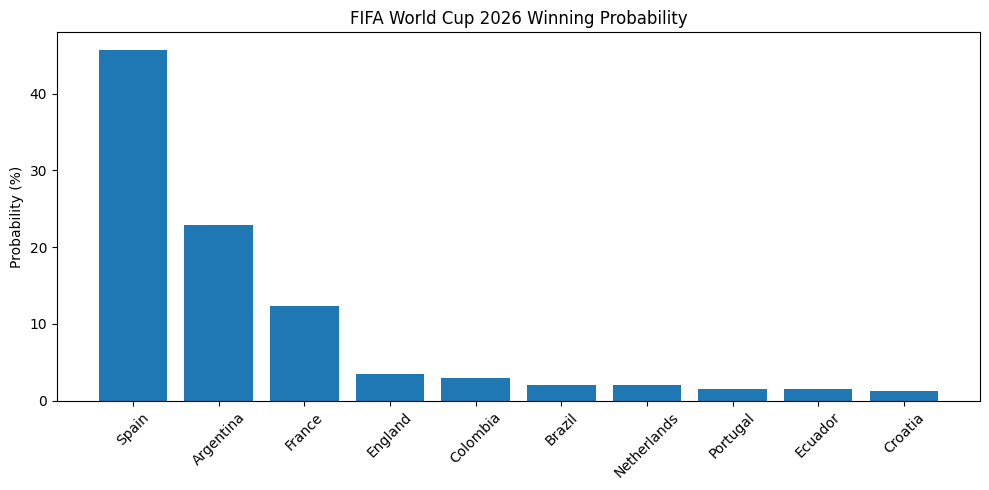

In [213]:
import matplotlib.pyplot as plt

top10 = champion_table.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["Team"], top10["Probability (%)"])
plt.xticks(rotation=45)
plt.ylabel("Probability (%)")
plt.title("FIFA World Cup 2026 Winning Probability")
plt.tight_layout()
plt.show()

In [214]:
features = create_match_features(
    "Spain",
    "Argentina",
    0,
    5,
    0
)

features = features[feature_columns]

print(model.predict_proba(features))

[[0.36327642 0.32460847 0.31211504]]


In [215]:
features = create_match_features(
    "Spain",
    "Brazil",
    0,
    5,
    0
)

features = features[feature_columns]

print(model.predict_proba(features))

[[0.0796002  0.24684684 0.67355293]]


In [216]:
features = create_match_features(
    "Spain",
    "France",
    0,
    5,
    0
)

features = features[feature_columns]

print(model.predict_proba(features))

[[0.25580418 0.18882315 0.5553727 ]]


In [217]:
features = create_match_features(
    "Argentina",
    "France",
    0,
    5,
    0
)

features = features[feature_columns]

print(model.predict_proba(features))

[[0.37327653 0.25294942 0.37377405]]


In [219]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                  Feature  Importance
2          elo_difference    0.271281
5         rank_difference    0.145479
0                home_elo    0.067846
1                away_elo    0.065914
3          home_fifa_rank    0.045862
4          away_fifa_rank    0.041270
11   goal_diff_difference    0.041160
8         form_difference    0.035195
16        tournament_type    0.035035
7        away_form_points    0.031755
9          home_goal_diff    0.030437
6        home_form_points    0.030221
14        wins_difference    0.029663
17  tournament_importance    0.028271
12        home_wins_last5    0.027158
13        away_wins_last5    0.026593
10         away_goal_diff    0.026259
15         host_advantage    0.020601


# Tracking Tournament Progress

To estimate each team's probability of progressing through the FIFA World Cup, every tournament simulation records the stage reached by each team.

For every simulation, the following statistics are stored:

- Group Winner
- Group Runner-up
- Best Third-place Team
- Qualified for Round of 32
- Reached Round of 16
- Reached Quarter-finals
- Reached Semi-finals
- Reached Final
- FIFA World Cup Champion

After thousands of simulations, these counts are converted into probabilities for every team.

In [222]:
def simulate_world_cup():

    # ---------------- Group Stage ----------------

    group_tables = simulate_all_groups(
        fixtures,
        verbose=False
    )

    winners, qualifiers = get_group_qualifiers(group_tables)

    third_place, best8 = get_best_third_placed(group_tables)

    qualified = get_qualified_teams(
        winners,
        qualifiers,
        best8
    )

    # ---------------- Round of 32 ----------------

    third_place_groups = sorted([
        key[0]
        for key in qualified.keys()
        if key.endswith("3")
    ])

    qualified_key = tuple(third_place_groups)

    third_place_mapping = third_place_lookup[qualified_key]

    round32 = build_round_of_32(
        qualified,
        third_place_mapping
    )

    round16_teams = simulate_round(round32)

    # ---------------- Round of 16 ----------------

    round16 = build_round_of_16(
        round16_teams
    )

    quarterfinal_teams = simulate_round(
        round16
    )

    # ---------------- Quarter-finals ----------------

    quarterfinals = build_quarterfinals(
        quarterfinal_teams
    )

    semifinal_teams = simulate_round(
        quarterfinals
    )

    # ---------------- Semi-finals ----------------

    semifinals = build_semifinals(
        semifinal_teams
    )

    finalists, third_place_teams = simulate_semifinals(
        semifinals
    )

    # ---------------- Final ----------------

    final_match, third_place_match = build_final_matches(
        finalists,
        third_place_teams
    )

    third_place_winner = simulate_knockout_match(
        third_place_teams[0],
        third_place_teams[1]
    )

    runner_up_third = (
        third_place_teams[1]
        if third_place_winner == third_place_teams[0]
        else third_place_teams[0]
    )

    champion = simulate_knockout_match(
        finalists[0],
        finalists[1]
    )

    runner_up = (
        finalists[1]
        if champion == finalists[0]
        else finalists[0]
    )

    # ---------------- Return Everything ----------------

    return {

        # Group Stage
        "group_winners": list(winners.values()),
        "group_runners": list(qualifiers.values()),
        "best_third": list(best8["Team"]),
        "qualified_r32": list(qualified.values()),

        # Knockout Progress
        "round16": round16_teams,
        "quarterfinals": quarterfinal_teams,
        "semifinals": semifinal_teams,
        "finalists": finalists,

        # Final Positions
        "champion": str(champion),
        "runner_up": str(runner_up),
        "third": str(third_place_winner),
        "fourth": str(runner_up_third)
    }

In [234]:
def simulate_world_cup():

    # ---------------- Group Stage ----------------

    group_tables = simulate_all_groups(
        fixtures,
        verbose=False
    )

    winners, qualifiers = get_group_qualifiers(
        group_tables
    )

    third_place, best8 = get_best_third_placed(
        group_tables
    )

    qualified = get_qualified_teams(
        winners,
        qualifiers,
        best8
    )

    # ---------------- Round of 32 ----------------

    third_place_groups = sorted([
        key[0]
        for key in qualified.keys()
        if key.endswith("3")
    ])

    qualified_key = tuple(third_place_groups)

    third_place_mapping = third_place_lookup[
        qualified_key
    ]

    round32 = build_round_of_32(
        qualified,
        third_place_mapping
    )

    round16_teams = simulate_round(round32)

    # ---------------- Round of 16 ----------------

    round16 = build_round_of_16(
        round16_teams
    )

    quarterfinal_teams = simulate_round(
        round16
    )

    # ---------------- Quarter-finals ----------------

    quarterfinals = build_quarterfinals(
        quarterfinal_teams
    )

    semifinal_teams = simulate_round(
        quarterfinals
    )

    # ---------------- Semi-finals ----------------

    semifinals = build_semifinals(
        semifinal_teams
    )

    finalists, third_place_teams = simulate_semifinals(
        semifinals
    )

    # ---------------- Final ----------------

    final_match, third_place_match = build_final_matches(
        finalists,
        third_place_teams
    )

    third_place_winner = simulate_knockout_match(
        third_place_teams[0],
        third_place_teams[1]
    )

    runner_up_third = (
        third_place_teams[1]
        if third_place_winner == third_place_teams[0]
        else third_place_teams[0]
    )

    champion = simulate_knockout_match(
        finalists[0],
        finalists[1]
    )

    runner_up = (
        finalists[1]
        if champion == finalists[0]
        else finalists[0]
    )

    # ---------------- Return Tournament ----------------

    return {

        # Group Stage
        "group_winners": list(winners.values()),

        "group_runners": [
            qualifiers[group][1]
            for group in sorted(qualifiers.keys())
        ],

        "best_third": list(best8["Team"]),

        "qualified_r32": list(qualified.values()),

        # Knockout Stages
        "round16": round16_teams,

        "quarterfinals": quarterfinal_teams,

        "semifinals": semifinal_teams,

        "finalists": finalists,

        # Final Standings
        "champion": str(champion),

        "runner_up": str(runner_up),

        "third": str(third_place_winner),

        "fourth": str(runner_up_third)
    }

In [235]:
(
group_winners,
group_runners,
best_third,
qualified_r32,
round16,
quarterfinals,
semifinals,
finalists,
champions
) = monte_carlo_simulation(100)

Completed 100/100 simulations (100.0%)

Simulation Finished!


In [236]:
def probability_table(counter, n_simulations):

    table = (
        pd.DataFrame(counter.items(), columns=["Team", "Count"])
        .sort_values("Count", ascending=False)
        .reset_index(drop=True)
    )

    table["Probability (%)"] = (
        table["Count"] / n_simulations * 100
    )

    return table

In [237]:
group_winner_table = probability_table(group_winners, 100)
group_runner_table = probability_table(group_runners, 100)
best_third_table = probability_table(best_third, 100)

qualified_r32_table = probability_table(qualified_r32, 100)

round16_table = probability_table(round16, 100)
quarterfinal_table = probability_table(quarterfinals, 100)
semifinal_table = probability_table(semifinals, 100)
final_table = probability_table(finalists, 100)

champion_table = probability_table(champions, 100)

In [238]:
all_teams = sorted(
    set(group_winners.keys())
    | set(group_runners.keys())
    | set(best_third.keys())
    | set(qualified_r32.keys())
    | set(round16.keys())
    | set(quarterfinals.keys())
    | set(semifinals.keys())
    | set(finalists.keys())
    | set(champions.keys())
)

In [239]:
progress = pd.DataFrame({
    "Team": all_teams
})

In [240]:
def add_probability_column(df, counter, name, sims):

    df[name] = (
        df["Team"]
        .map(counter)
        .fillna(0)
        / sims
        * 100
    )

    return df

In [241]:
progress = add_probability_column(progress, group_winners, "Group Winner", 100)

progress = add_probability_column(progress, group_runners, "Group Runner-up", 100)

progress = add_probability_column(progress, best_third, "Best Third", 100)

progress = add_probability_column(progress, qualified_r32, "Round of 32", 100)

progress = add_probability_column(progress, round16, "Round of 16", 100)

progress = add_probability_column(progress, quarterfinals, "Quarter-final", 100)

progress = add_probability_column(progress, semifinals, "Semi-final", 100)

progress = add_probability_column(progress, finalists, "Final", 100)

progress = add_probability_column(progress, champions, "Champion", 100)

In [242]:
progress = progress.sort_values(
    "Champion",
    ascending=False
).reset_index(drop=True)

progress

,Team,Group Winner,Group Runner-up,Best Third,Round of 32,Round of 16,Quarter-final,Semi-final,Final,Champion
0,Spain,89.0,11.0,0.0,100.0,91.0,83.0,79.0,62.0,43.0
1,Argentina,91.0,6.0,1.0,98.0,81.0,74.0,63.0,50.0,25.0
2,France,66.0,25.0,6.0,97.0,90.0,64.0,43.0,20.0,10.0
3,Colombia,45.0,41.0,12.0,98.0,71.0,42.0,14.0,9.0,6.0
4,Brazil,59.0,26.0,10.0,95.0,61.0,41.0,29.0,12.0,5.0
5,Ecuador,54.0,37.0,8.0,99.0,68.0,45.0,19.0,5.0,3.0
6,Netherlands,60.0,32.0,5.0,97.0,68.0,43.0,29.0,10.0,2.0
7,England,63.0,29.0,5.0,97.0,75.0,48.0,28.0,5.0,2.0
8,Morocco,36.0,46.0,14.0,96.0,28.0,3.0,3.0,1.0,1.0
9,Senegal,12.0,33.0,35.0,80.0,48.0,19.0,3.0,1.0,1.0


In [243]:
progress.iloc[:, 1:] = progress.iloc[:, 1:].round(2)

In [244]:
progress.to_csv(
    "team_progression_probabilities.csv",
    index=False
)

In [246]:
(
    group_winners,
    group_runners,
    best_third,
    qualified_r32,
    round16,
    quarterfinals,
    semifinals,
    finalists,
    champions
) = monte_carlo_simulation(500)

Completed 500/500 simulations (100.0%)

Simulation Finished!


In [247]:
group_winner_table = probability_table(group_winners, 500)
group_runner_table = probability_table(group_runners, 500)
best_third_table = probability_table(best_third, 500)

qualified_r32_table = probability_table(qualified_r32, 500)

round16_table = probability_table(round16, 500)
quarterfinal_table = probability_table(quarterfinals, 500)
semifinal_table = probability_table(semifinals, 500)
final_table = probability_table(finalists, 500)

champion_table = probability_table(champions, 500)

In [248]:
all_teams = sorted(
    set(group_winners.keys())
    | set(group_runners.keys())
    | set(best_third.keys())
    | set(qualified_r32.keys())
    | set(round16.keys())
    | set(quarterfinals.keys())
    | set(semifinals.keys())
    | set(finalists.keys())
    | set(champions.keys())
)

progress = pd.DataFrame({
    "Team": all_teams
})

In [249]:
progress = add_probability_column(progress, group_winners, "Group Winner", 500)
progress = add_probability_column(progress, group_runners, "Group Runner-up", 500)
progress = add_probability_column(progress, best_third, "Best Third", 500)
progress = add_probability_column(progress, qualified_r32, "Qualified for R32", 500)
progress = add_probability_column(progress, round16, "Round of 16", 500)
progress = add_probability_column(progress, quarterfinals, "Quarter-final", 500)
progress = add_probability_column(progress, semifinals, "Semi-final", 500)
progress = add_probability_column(progress, finalists, "Final", 500)
progress = add_probability_column(progress, champions, "Champion", 500)

In [251]:
progress = (
    progress
    .sort_values("Champion", ascending=False)
    .reset_index(drop=True)
)

progress.iloc[:, 1:] = progress.iloc[:, 1:].round(2)

progress.head(30)

,Team,Group Winner,Group Runner-up,Best Third,Qualified for R32,Round of 16,Quarter-final,Semi-final,Final,Champion
0,Spain,86.4,12.8,0.8,100.0,88.2,76.0,68.4,58.2,44.2
1,Argentina,89.2,8.2,2.2,99.6,78.0,69.4,54.8,46.6,24.0
2,France,60.4,26.2,10.6,97.2,86.6,65.4,44.8,18.6,11.0
3,England,59.2,31.8,7.4,98.4,69.2,44.8,24.2,9.6,3.2
4,Colombia,49.2,38.0,8.4,95.6,62.6,41.8,18.4,9.2,2.6
5,Brazil,59.0,24.2,13.6,96.8,60.8,44.2,27.8,9.6,2.4
6,Portugal,43.0,37.6,12.8,93.4,63.4,37.8,13.0,6.0,2.2
7,Croatia,34.4,50.0,11.6,96.0,58.6,29.0,14.2,5.4,2.0
8,Türkiye,58.0,25.2,10.2,93.4,67.6,41.4,10.0,3.4,1.6
9,Germany,46.0,46.4,6.0,98.4,54.6,31.2,14.4,3.0,1.4


In [252]:
import pickle

with open("checkpoint_500.pkl", "wb") as f:
    pickle.dump({
        "progress": progress,
        "champions": champions
    }, f)

In [253]:
N_SIMULATIONS = 10000

In [254]:
(
    group_winners,
    group_runners,
    best_third,
    qualified_r32,
    round16,
    quarterfinals,
    semifinals,
    finalists,
    champions
) = monte_carlo_simulation(N_SIMULATIONS)

Completed 10000/10000 simulations (100.0%)

Simulation Finished!


In [257]:
group_winner_table = probability_table(
    group_winners,
    N_SIMULATIONS
)

group_runner_table = probability_table(
    group_runners,
    N_SIMULATIONS
)

best_third_table = probability_table(
    best_third,
    N_SIMULATIONS
)

qualified_r32_table = probability_table(
    qualified_r32,
    N_SIMULATIONS
)

round16_table = probability_table(
    round16,
    N_SIMULATIONS
)

quarterfinal_table = probability_table(
    quarterfinals,
    N_SIMULATIONS
)

semifinal_table = probability_table(
    semifinals,
    N_SIMULATIONS
)

final_table = probability_table(
    finalists,
    N_SIMULATIONS
)

champion_table = probability_table(
    champions,
    N_SIMULATIONS
)

In [258]:
all_teams = sorted(
    set(group_winners.keys())
    | set(group_runners.keys())
    | set(best_third.keys())
    | set(qualified_r32.keys())
    | set(round16.keys())
    | set(quarterfinals.keys())
    | set(semifinals.keys())
    | set(finalists.keys())
    | set(champions.keys())
)

In [259]:
progress = pd.DataFrame({
    "Team": all_teams
})

In [260]:
progress = add_probability_column(
    progress,
    group_winners,
    "Group Winner",
    N_SIMULATIONS
)

progress = add_probability_column(
    progress,
    group_runners,
    "Group Runner-up",
    N_SIMULATIONS
)

progress = add_probability_column(
    progress,
    best_third,
    "Best Third",
    N_SIMULATIONS
)

progress = add_probability_column(
    progress,
    qualified_r32,
    "Qualified for R32",
    N_SIMULATIONS
)

progress = add_probability_column(
    progress,
    round16,
    "Round of 16",
    N_SIMULATIONS
)

progress = add_probability_column(
    progress,
    quarterfinals,
    "Quarter-final",
    N_SIMULATIONS
)

progress = add_probability_column(
    progress,
    semifinals,
    "Semi-final",
    N_SIMULATIONS
)

progress = add_probability_column(
    progress,
    finalists,
    "Final",
    N_SIMULATIONS
)

progress = add_probability_column(
    progress,
    champions,
    "Champion",
    N_SIMULATIONS
)

In [261]:
progress = (
    progress
    .sort_values(
        "Champion",
        ascending=False
    )
    .reset_index(drop=True)
)

progress.iloc[:, 1:] = progress.iloc[:, 1:].round(2)

progress

,Team,Group Winner,Group Runner-up,Best Third,Qualified for R32,Round of 16,Quarter-final,Semi-final,Final,Champion
0,Spain,87.86,11.52,0.48,99.86,87.67,78.19,71.33,59.20,45.28
1,Argentina,89.28,8.78,1.51,99.57,78.34,68.20,56.38,47.15,23.47
2,France,64.17,25.51,8.46,98.14,87.74,65.61,45.51,19.91,12.19
3,England,60.91,31.61,6.03,98.55,70.83,44.74,24.37,8.06,3.32
4,Colombia,53.36,34.91,7.87,96.14,67.45,43.71,18.41,9.36,2.80
5,Netherlands,56.51,35.20,6.05,97.76,66.96,37.37,24.37,9.66,2.13
6,Brazil,61.28,24.85,10.28,96.41,60.59,39.54,25.62,8.72,2.00
7,Portugal,40.20,42.20,10.94,93.34,61.39,35.71,12.90,6.14,1.67
8,Ecuador,49.08,41.72,6.96,97.76,61.84,39.85,19.02,5.74,1.60
9,Croatia,35.22,50.19,10.58,95.99,58.03,27.61,12.17,3.68,1.11


In [262]:
champion_table

,Team,Count,Probability (%)
0,Spain,4528,45.28
1,Argentina,2347,23.47
2,France,1219,12.19
3,England,332,3.32
4,Colombia,280,2.80
5,Netherlands,213,2.13
6,Brazil,200,2.00
7,Portugal,167,1.67
8,Ecuador,160,1.60
9,Croatia,111,1.11


In [263]:
progress.to_csv(
    "team_progression_probabilities.csv",
    index=False
)

champion_table.to_csv(
    "champion_probabilities.csv",
    index=False
)

group_winner_table.to_csv(
    "group_winner_probabilities.csv",
    index=False
)

group_runner_table.to_csv(
    "group_runner_probabilities.csv",
    index=False
)

best_third_table.to_csv(
    "best_third_probabilities.csv",
    index=False
)

qualified_r32_table.to_csv(
    "qualified_r32_probabilities.csv",
    index=False
)

round16_table.to_csv(
    "round16_probabilities.csv",
    index=False
)

quarterfinal_table.to_csv(
    "quarterfinal_probabilities.csv",
    index=False
)

semifinal_table.to_csv(
    "semifinal_probabilities.csv",
    index=False
)

final_table.to_csv(
    "final_probabilities.csv",
    index=False
)

In [264]:
import os

csv_files = sorted(
    [f for f in os.listdir() if f.endswith(".csv")]
)

print(f"Total CSV files: {len(csv_files)}\n")

for file in csv_files:
    print(file)

Total CSV files: 13

best_third_probabilities.csv
champion_probabilities.csv
final_probabilities.csv
fourth_place_probabilities.csv
group_runner_probabilities.csv
group_winner_probabilities.csv
qualified_r32_probabilities.csv
quarterfinal_probabilities.csv
round16_probabilities.csv
runner_up_probabilities.csv
semifinal_probabilities.csv
team_progression_probabilities.csv
third_place_probabilities.csv


In [265]:
champion_table.head(10)

,Team,Count,Probability (%)
0,Spain,4528,45.28
1,Argentina,2347,23.47
2,France,1219,12.19
3,England,332,3.32
4,Colombia,280,2.80
5,Netherlands,213,2.13
6,Brazil,200,2.00
7,Portugal,167,1.67
8,Ecuador,160,1.60
9,Croatia,111,1.11


In [266]:
progress.head(10)

,Team,Group Winner,Group Runner-up,Best Third,Qualified for R32,Round of 16,Quarter-final,Semi-final,Final,Champion
0,Spain,87.86,11.52,0.48,99.86,87.67,78.19,71.33,59.20,45.28
1,Argentina,89.28,8.78,1.51,99.57,78.34,68.20,56.38,47.15,23.47
2,France,64.17,25.51,8.46,98.14,87.74,65.61,45.51,19.91,12.19
3,England,60.91,31.61,6.03,98.55,70.83,44.74,24.37,8.06,3.32
4,Colombia,53.36,34.91,7.87,96.14,67.45,43.71,18.41,9.36,2.80
5,Netherlands,56.51,35.20,6.05,97.76,66.96,37.37,24.37,9.66,2.13
6,Brazil,61.28,24.85,10.28,96.41,60.59,39.54,25.62,8.72,2.00
7,Portugal,40.20,42.20,10.94,93.34,61.39,35.71,12.90,6.14,1.67
8,Ecuador,49.08,41.72,6.96,97.76,61.84,39.85,19.02,5.74,1.60
9,Croatia,35.22,50.19,10.58,95.99,58.03,27.61,12.17,3.68,1.11


In [267]:
import joblib

joblib.dump(model, "world_cup_prediction_model.pkl")

['world_cup_prediction_model.pkl']

In [268]:
import joblib

joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [271]:
joblib.dump(model, "world_cup_prediction_model.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")
joblib.dump(third_place_lookup, "third_place_lookup.pkl")

['third_place_lookup.pkl']